# Edinburgh Airbnb — EDA Part 1: Summary Statistics & Distributions

Working from `listings_master.csv` (the cleaned, enriched flat table) for this
notebook - faster to iterate on in pandas than going through SQL joins for
every single chart.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/processed/edinburgh/listings_master.csv", low_memory=False)
print(f"{len(df):,} listings loaded")

Matplotlib is building the font cache; this may take a moment.


4,925 listings loaded


## Descriptive statistics on key numeric fields

In [3]:
key_numeric_cols = [
    "price_clean", "accommodates", "bedrooms", "bathrooms",
    "minimum_nights", "number_of_reviews", "review_scores_rating",
    "host_tenure_years", "occupancy_rate", "reviews_per_month",
]
df[key_numeric_cols].describe().round(2)

,price_clean,accommodates,bedrooms,bathrooms,minimum_nights,number_of_reviews,review_scores_rating,host_tenure_years,occupancy_rate,reviews_per_month
count,4925.00,4925.00,4922.00,4922.00,4925.00,4925.00,4645.00,4923.00,4925.00,4645.00
mean,300.52,3.53,1.65,1.30,3.07,113.50,4.78,7.97,0.55,2.82
std,1206.05,2.04,0.98,0.65,13.31,153.17,0.29,3.66,0.32,2.41
min,18.00,1.00,0.00,0.00,1.00,0.00,1.00,0.04,0.00,0.01
25%,108.00,2.00,1.00,1.00,1.00,11.00,4.70,5.56,0.24,1.04
50%,160.00,3.00,1.00,1.00,2.00,53.00,4.85,8.82,0.59,2.29
75%,237.00,4.00,2.00,1.50,3.00,159.00,4.95,10.50,0.85,4.06
max,18465.00,16.00,12.00,12.00,365.00,1541.00,5.00,15.93,1.00,35.23


The median nightly price for an Edinburgh Airbnb listing is £160, while the mean price is substantially higher at £301. This indicates a right-skewed distribution, where a relatively small number of expensive listings increase the overall average price.

Prices range from £18 to £18,465 per night, highlighting considerable variation across the market. The standard deviation (£1,206) is much larger than the median price, further suggesting the presence of extreme high-price listings and substantial dispersion in listing prices.

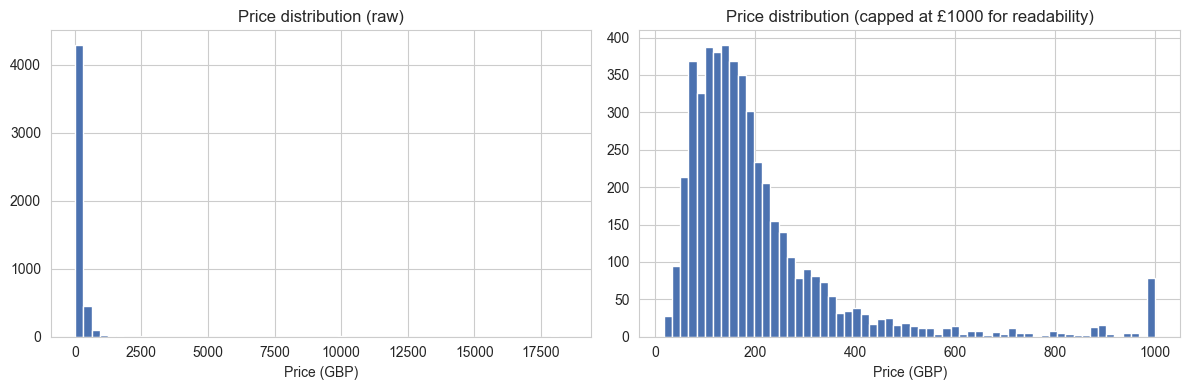

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price_clean"], bins=60, color="#4C72B0")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price (GBP)")

axes[1].hist(df["price_clean"].apply(lambda x: x if x <= 0 else x).clip(upper=1000), bins=60, color="#4C72B0")
axes[1].set_title("Price distribution (capped at £1000 for readability)")
axes[1].set_xlabel("Price (GBP)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig01_price_distribution.png", dpi=150)
plt.show()

**Figure 1: Price distribution.** The price distribution is strongly right-skewed, with most listings concentrated between approximately £75 and £250 per night and a long tail extending towards very high prices. The capped histogram makes this pattern easier to see, revealing that the majority of Edinburgh listings fall within a relatively narrow price range while a small number of luxury properties are priced substantially higher.

This skew explains why the mean price (£301) is much higher than the median (£160). For platform operators and analysts, relying solely on average price would overstate what a typical guest is likely to pay, making median price a more representative measure of the market.

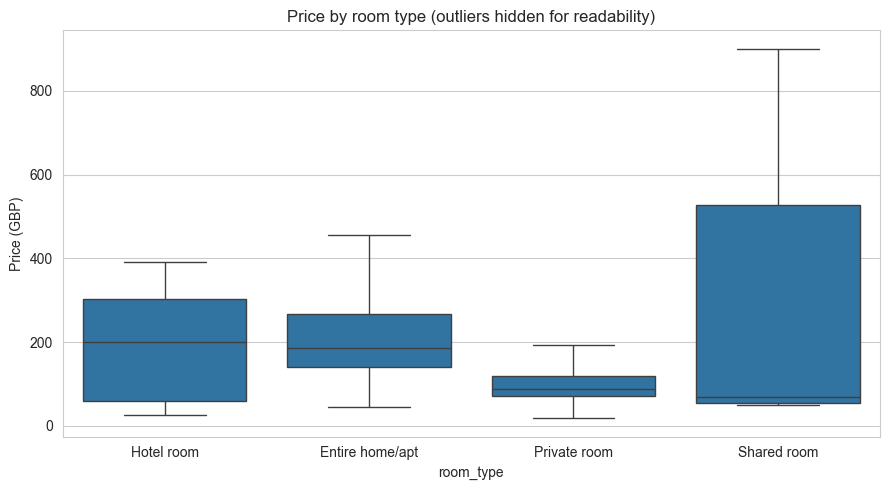

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby("room_type")["price_clean"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="price_clean", order=order, ax=ax, showfliers=False)
ax.set_title("Price by room type (outliers hidden for readability)")
ax.set_ylabel("Price (GBP)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig02_price_by_room_type.png", dpi=150)
plt.show()

**Figure 2: Price by room type.** Room type appears to be a major driver of listing price in the Edinburgh Airbnb market. Private rooms have the lowest prices overall, while entire homes/apartments command substantially higher prices and exhibit a wider spread, reflecting greater variation between budget and premium properties.

The pattern is broadly consistent with the SQL analysis from the star schema. Entire homes/apartments recorded the highest average prices (£313 for non-superhosts and £431 for superhosts), while private rooms were considerably cheaper. The larger price spread visible for entire homes also suggests that this category contains both relatively affordable properties and high-end luxury listings, contributing to the strong right-skew observed in the overall price distribution.

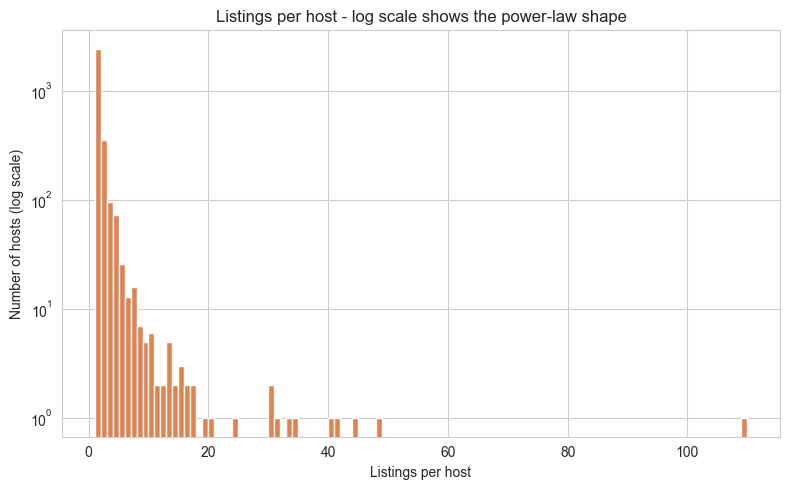

79.4% of hosts have exactly 1 listing
Top 10% of hosts (by listing count) control 38.0% of all listings


In [6]:
listings_per_host = df["host_id"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(listings_per_host, bins=range(1, listings_per_host.max() + 2), color="#DD8452")
ax.set_yscale("log")
ax.set_xlabel("Listings per host")
ax.set_ylabel("Number of hosts (log scale)")
ax.set_title("Listings per host - log scale shows the power-law shape")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig03_listings_per_host.png", dpi=150)
plt.show()

pct_single_listing_hosts = (listings_per_host == 1).mean() * 100
top_10pct_hosts_share = listings_per_host.sort_values(ascending=False).head(
    int(len(listings_per_host) * 0.1)
).sum() / listings_per_host.sum() * 100

print(f"{pct_single_listing_hosts:.1f}% of hosts have exactly 1 listing")
print(f"Top 10% of hosts (by listing count) control {top_10pct_hosts_share:.1f}% of all listings")

**Figure 3: Listings per host.** The distribution of listings per host follows a clear power-law pattern. Most hosts operate only a single property, with 79.4% of hosts having exactly one listing, while the number of hosts falls rapidly as portfolio size increases.

Despite the large number of single-listing hosts, supply is still somewhat concentrated among larger operators. The top 10% of hosts by listing count control 38.0% of all listings, indicating that a relatively small group of professional or semi-professional hosts accounts for a substantial share of the Edinburgh Airbnb market. This suggests that both casual hosts and larger multi-property operators play important roles in overall market supply.

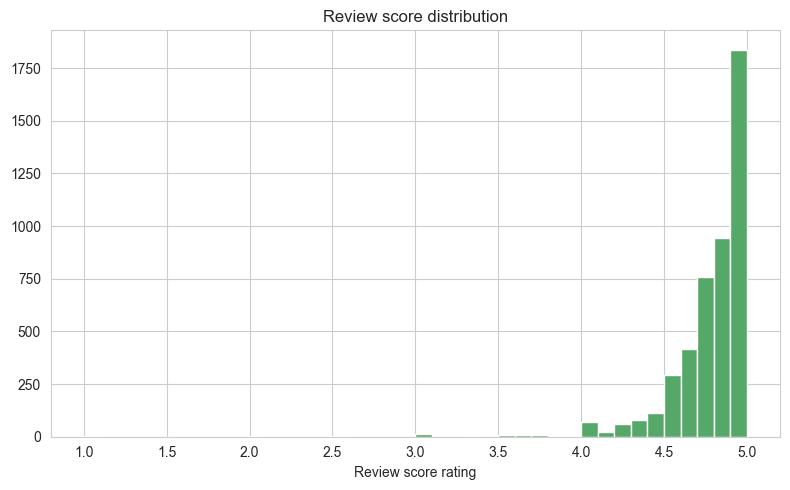

58.4% of rated listings score 4.8 or above


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["review_scores_rating"].dropna(), bins=40, color="#55A868")
ax.set_xlabel("Review score rating")
ax.set_title("Review score distribution")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig04_review_score_distribution.png", dpi=150)
plt.show()

pct_above_4_8 = (df["review_scores_rating"] >= 4.8).mean() * 100
print(f"{pct_above_4_8:.1f}% of rated listings score 4.8 or above")

**Figure 4: Review scores.** Review scores are heavily concentrated at the upper end of the scale, with most listings receiving ratings between approximately 4.7 and 5.0. Rather than being evenly distributed, the ratings exhibit a strong clustering effect near the maximum possible score, indicating that highly rated listings are the norm rather than the exception.

Overall, 58.4% of rated listings have a review score of 4.8 or higher. This suggests that review scores should be interpreted relative to the platform rather than in absolute terms. In a market where most listings score close to 5.0, a rating of 4.6 may represent a genuinely below-average listing rather than simply a "good" one, making small differences in ratings more meaningful than they initially appear.

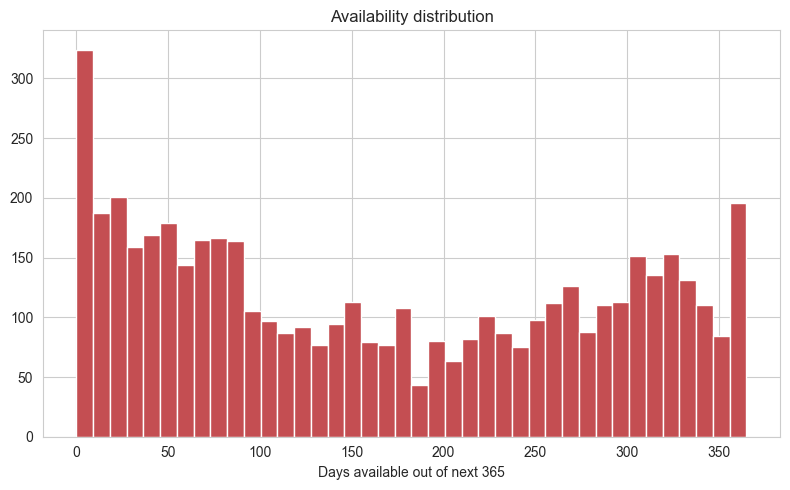

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["availability_365"], bins=40, color="#C44E52")
ax.set_xlabel("Days available out of next 365")
ax.set_title("Availability distribution")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig05_availability_distribution.png", dpi=150)
plt.show()

**Figure 5: Availability.** The availability distribution is not uniform and shows evidence of clustering at both ends of the scale. There is a noticeable concentration of listings with very low availability (close to 0 days available) as well as a second concentration near 365 days available, suggesting that hosts use the platform in different ways.

Listings with very low availability may represent highly booked properties or listings that hosts have largely blocked from the calendar, while listings with very high availability may indicate lower-demand properties or hosts keeping their calendars open year-round. This pattern suggests the Edinburgh Airbnb market contains a mix of highly active listings and listings that are either rarely booked or only intermittently used, rather than a single homogeneous group of hosts.